In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class TextPreprocessor:
    
    def __init__(self):
        self.stopwords = set([
            'yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara', 
            'dia', 'dua', 'ia', 'seperti', 'jika', 'jika', 'sehingga', 'kembali', 
            'dan', 'ini', 'itu', 'atau', 'adalah', 'dengan', 'dari', 'di', 
            'akan', 'oleh', 'tidak', 'telah', 'dalam', 'bisa', 'ada', 'juga',
            'dapat', 'sudah', 'saya', 'ya', 'aja', 'nya', 'si', 'lagi'
        ])
    
    def clean_text(self, text):
        """Membersihkan text dari karakter tidak perlu"""
        if pd.isna(text):
            return ""
        
        text = text.lower()
        
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        text = re.sub(r'@\w+|#\w+', '', text)
        
        text = re.sub(r'\d+', '', text)
        
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        text = ' '.join(text.split())
        
        return text
    
    def remove_stopwords(self, text):
        words = text.split()
        filtered_words = [word for word in words if word not in self.stopwords]
        return ' '.join(filtered_words)
    
    def preprocess(self, text):
        text = self.clean_text(text)
        text = self.remove_stopwords(text)
        return text

In [3]:
df = pd.read_csv('../datasets/tweets_with_sentiment.csv')

In [4]:
print(f"Jumlah data: {len(df)} baris")
print(f"\nKolom dataset: {df.columns.tolist()}")
print(f"\n5 Data Pertama:")
print(df.head())

Jumlah data: 5376 baris

Kolom dataset: ['text', 'sentiment']

5 Data Pertama:
                                                text sentiment
0              @CHAEMINLE masuk akal... boleh jugaaa  negative
1  @valuidation seenggaknya ini lebih masuk akal ...  positive
2  harusnya menkeu lebih paham ya soal keuangan t...  negative
3                            https://t.co/aLn3SHwcK0   neutral
4  @s1bayy @pete_rizzo_ Ya, klaim itu masuk akal ...   neutral


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5376 entries, 0 to 5375
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       5376 non-null   object
 1   sentiment  5376 non-null   object
dtypes: object(2)
memory usage: 84.1+ KB
None


In [6]:
print(f"\Distribusi Sentimen:")
print(df['sentiment'].value_counts())
print(f"\nPersentase:")
print(df['sentiment'].value_counts(normalize=True) * 100)

\Distribusi Sentimen:
sentiment
negative    2848
positive    1788
neutral      740
Name: count, dtype: int64

Persentase:
sentiment
negative    52.976190
positive    33.258929
neutral     13.764881
Name: proportion, dtype: float64


In [7]:
preprocessor = TextPreprocessor()


In [8]:
print("\n" + "="*70)
print("SECTION 3: DATA PREPROCESSING")
print("="*70)

print(f"\n🔍 Cek missing values:")
print(df.isnull().sum())

df = df.dropna(subset=['text', 'sentiment'])
print(f"\n✅ Data setelah hapus missing: {len(df)} baris")

print("\n🔄 Melakukan preprocessing text...")
df['cleaned_text'] = df['text'].apply(preprocessor.preprocess)

# Hapus text kosong setelah preprocessing
df = df[df['cleaned_text'].str.strip() != '']
print(f"✅ Data setelah preprocessing: {len(df)} baris")



SECTION 3: DATA PREPROCESSING

🔍 Cek missing values:
text         0
sentiment    0
dtype: int64

✅ Data setelah hapus missing: 5376 baris

🔄 Melakukan preprocessing text...
✅ Data setelah preprocessing: 5334 baris


In [9]:
tfidf = TfidfVectorizer(
    max_features=3000,      # Maksimal 5000 fitur
    ngram_range=(1, 2),     # Unigram dan bigram
    min_df=2,               # Min document frequency
    max_df=0.8              # Max document frequency
)

In [10]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

In [11]:
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment_encoded']

In [12]:

print(f"✅ Fitur berhasil diekstrak!")
print(f"Shape fitur (X): {X.shape}")
print(f"Shape label (y): {y.shape}")
print(f"\nJumlah vocabulary: {len(tfidf.vocabulary_)}")

✅ Fitur berhasil diekstrak!
Shape fitur (X): (5334, 3000)
Shape label (y): (5334,)

Jumlah vocabulary: 3000


In [13]:
print(f"\n📌 10 Fitur teratas (berdasarkan TF-IDF):")
feature_names = tfidf.get_feature_names_out()
print(feature_names[:10])


📌 10 Fitur teratas (berdasarkan TF-IDF):
['abang' 'abis' 'able' 'able to' 'about' 'about how' 'about it'
 'about the' 'absolutely' 'abt']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [15]:

print("\n" + "="*70)
print("SECTION 7: TRAINING MODEL SVM")
print("="*70)

print("\n🚀 Memulai training model SVM...")
print("⏳ Mohon tunggu, proses ini mungkin memakan waktu...")

# Inisialisasi SVM dengan kernel RBF
svm_model = SVC(
    kernel='rbf',           # Kernel: 'linear', 'rbf', 'poly', 'sigmoid'
    C=1.0,                  # Regularization parameter
    gamma='scale',          # Kernel coefficient
    random_state=42,
    verbose=True,
    probability=True
)

svm_model.fit(X_train, y_train)



SECTION 7: TRAINING MODEL SVM

🚀 Memulai training model SVM...
⏳ Mohon tunggu, proses ini mungkin memakan waktu...
[LibSVM]

SVC(probability=True, random_state=42, verbose=True)

In [16]:
print("\n🔮 Melakukan prediksi pada test set...")
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy*100:.2f}%")



🔮 Melakukan prediksi pada test set...

🎯 Accuracy: 70.20%


In [17]:
print(f"\n📋 Classification Report:")
print("="*60)
target_names = le.classes_
print(classification_report(y_test, y_pred, target_names=target_names))


📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.90      0.78       569
     neutral       0.80      0.23      0.36       141
    positive       0.73      0.57      0.64       357

    accuracy                           0.70      1067
   macro avg       0.74      0.57      0.59      1067
weighted avg       0.72      0.70      0.68      1067



In [18]:
print(f"\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


📊 Confusion Matrix:
[[511   5  53]
 [ 85  33  23]
 [149   3 205]]


✅ Confusion matrix disimpan sebagai 'confusion_matrix.png'


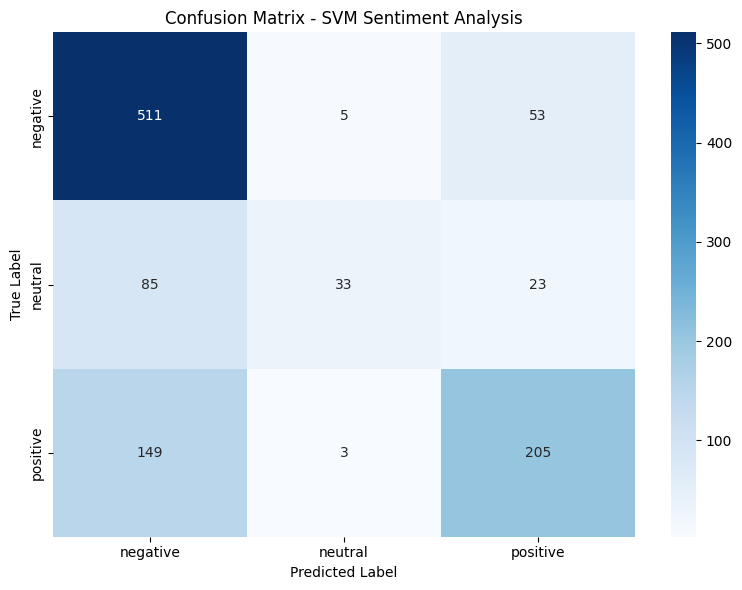

In [19]:

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix - SVM Sentiment Analysis')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Confusion matrix disimpan sebagai 'confusion_matrix.png'")

In [20]:

print("\n" + "="*70)
print("SECTION 9: TESTING DENGAN TEXT BARU")
print("="*70)

def predict_sentiment(text, model, vectorizer, label_encoder, preprocessor):
    """Fungsi untuk prediksi sentimen text baru"""
    cleaned = preprocessor.preprocess(text)
    
    text_vector = vectorizer.transform([cleaned])
    
    prediction = model.predict(text_vector)
    sentiment = label_encoder.inverse_transform(prediction)[0]
    
    return sentiment

test_texts = [
    "Produk ini sangat bagus dan berkualitas!",
    "Kecewa dengan pelayanan yang buruk",
    "Biasa aja sih, tidak terlalu istimewa",
    "Recommended! Puas banget dengan pembelian ini",
    "Mengecewakan, tidak sesuai ekspektasi"
]



SECTION 9: TESTING DENGAN TEXT BARU


In [21]:
print("\n🧪 Testing dengan text baru:")
print("="*60)
for i, text in enumerate(test_texts, 1):
    sentiment = predict_sentiment(text, svm_model, tfidf, le, preprocessor)
    print(f"\n{i}. Text: {text}")
    print(f"   Sentiment: {sentiment}")


🧪 Testing dengan text baru:

1. Text: Produk ini sangat bagus dan berkualitas!
   Sentiment: positive

2. Text: Kecewa dengan pelayanan yang buruk
   Sentiment: positive

3. Text: Biasa aja sih, tidak terlalu istimewa
   Sentiment: negative

4. Text: Recommended! Puas banget dengan pembelian ini
   Sentiment: positive

5. Text: Mengecewakan, tidak sesuai ekspektasi
   Sentiment: negative


In [22]:
import pickle

print("\n💾 Menyimpan model dan komponen...")

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Model berhasil disimpan!")
print("   - svm_model.pkl")
print("   - tfidf_vectorizer.pkl")
print("   - label_encoder.pkl")
print("   - preprocessor.pkl")



💾 Menyimpan model dan komponen...
✅ Model berhasil disimpan!
   - svm_model.pkl
   - tfidf_vectorizer.pkl
   - label_encoder.pkl
   - preprocessor.pkl


In [23]:

print("\n" + "="*70)
print("SUMMARY HASIL ANALISIS")
print("="*70)
print(f"""
Dataset Information:
- Total data: {len(df)} samples
- Training data: {len(y_train)} samples
- Testing data: {len(y_test)} samples
- Jumlah fitur (TF-IDF): {X.shape[1]}

Model Performance:
- Accuracy: {accuracy*100:.2f}%
- Kernel: RBF
- Support Vectors: {sum(svm_model.n_support_)}

Label Distribution:
{df['sentiment'].value_counts().to_string()}
""")

print("\Analisis sentimen selesai!")
print("="*70)


SUMMARY HASIL ANALISIS

Dataset Information:
- Total data: 5334 samples
- Training data: 4267 samples
- Testing data: 1067 samples
- Jumlah fitur (TF-IDF): 3000

Model Performance:
- Accuracy: 70.20%
- Kernel: RBF
- Support Vectors: 3726

Label Distribution:
sentiment
negative    2844
positive    1784
neutral      706

\Analisis sentimen selesai!
